In [1]:
import pandas as pd
import numpy as np
import datetime
from epiweeks import Week
import epiweeks
from collections import defaultdict
from pathlib import Path
import requests
import os
from datetime import datetime
from datetime import date, timedelta
from sodapy import Socrata
import warnings

import covidcast
from delphi_epidata import Epidata

covidcast.use_api_key("4bee67d2520898")


warnings.filterwarnings('ignore')

In [ ]:
# try to add in Delphi versioned data for categorical ensemble

In [43]:
TODAY = datetime.now()

# Convert dates to epiweeks
start_week = Week.fromdate(date(2025, 10, 1))
end_week = Week.fromdate(TODAY)

start_epiweek = int(f"{start_week.year}{start_week.week:02d}")
end_epiweek = int(f"{end_week.year}{end_week.week:02d}")

result_adm = Epidata.covidcast(data_source='nhsn', signals='confirmed_admissions_flu_ew_prelim',
    time_type='week', geo_type='state', time_values=Epidata.range(start_epiweek, end_epiweek), geo_value='*',
                              issues='*')
result_adm_us = Epidata.covidcast(data_source='nhsn', signals='confirmed_admissions_flu_ew_prelim',
    time_type='week', geo_type='nation', time_values=Epidata.range(start_epiweek, end_epiweek), geo_value='*',
                              issues='*')

# Convert to DataFrame
if result_adm['result'] == 1:
    dfadm = pd.DataFrame(result_adm['epidata'])
    dfadm_us = pd.DataFrame(result_adm_us['epidata'])
    #print(dfadm[['time_value', 'value', 'issue']])
else:
    print(f"No results: {result_adm.get('message')}")

dfadm = dfadm[['geo_value', 'time_value','issue','value']]
dfadm_us = dfadm_us[['geo_value', 'time_value','issue','value']]


df = pd.concat([dfadm, dfadm_us])

df['issue_date'] = df['issue'].apply(lambda x: Week(x//100, x %100).enddate())
df['target_end_date'] = df['time_value'].apply(lambda x: Week(x//100, x %100).enddate())

df['abbreviation'] = df['geo_value'].apply(lambda x: x.upper())

locations = pd.read_csv('./locations.csv')[['abbreviation', 'location', 'location_name']]

df = df.merge(locations, on='abbreviation')

In [44]:
df

,geo_value,time_value,issue,value,issue_date,target_end_date,abbreviation,location,location_name
0,ak,202540,202547,2.0,2025-11-22,2025-10-04,AK,02,Alaska
1,ak,202540,202548,2.0,2025-11-29,2025-10-04,AK,02,Alaska
2,ak,202540,202549,2.0,2025-12-06,2025-10-04,AK,02,Alaska
3,ak,202540,202550,2.0,2025-12-13,2025-10-04,AK,02,Alaska
4,ak,202540,202551,2.0,2025-12-20,2025-10-04,AK,02,Alaska
...,...,...,...,...,...,...,...,...,...
6196,us,202601,202603,29080.0,2026-01-24,2026-01-10,US,US,US
6197,us,202601,202604,29360.0,2026-01-31,2026-01-10,US,US,US
6198,us,202602,202603,17268.0,2026-01-24,2026-01-17,US,US,US
6199,us,202602,202604,18893.0,2026-01-31,2026-01-17,US,US,US


In [47]:
reference_date = '2026-01-17'
loc = 'US'
last_obs = pd.to_datetime(reference_date) - timedelta(days=7)
    
#obs_vers = df.copy()
obs_vers['target_end_date'] = pd.to_datetime(obs_vers['target_end_date'])
obs_vers['issue_date'] = pd.to_datetime(obs_vers['issue_date'])
obs_subset = obs_vers[(obs_vers.location == loc) &  (obs_vers.target_end_date == last_obs) &\
                      (obs_vers.issue_date==pd.to_datetime(reference_date))]

In [48]:
obs_subset

,geo_value,time_value,issue,value,issue_date,target_end_date,abbreviation,location,location_name


In [51]:
covidcast.__version__

AttributeError: module 'covidcast' has no attribute '__version__'

In [61]:
pd.to_datetime(Week.fromdate(datetime.now()).enddate()) +timedelta(days=3)

Timestamp('2026-02-10 00:00:00')

In [ ]:
# previous code

# Get observed value
last_obs = pd.to_datetime(reference_date) - timedelta(days=7)
try:
    obs_date = last_obs.strftime('%Y-%m-%d')
    obs_vers = pd.read_csv(f'https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/auxiliary-data/target-data-archive/target-hospital-admissions_{obs_date}.csv')
    obs_vers['date'] = pd.to_datetime(obs_vers['date'])
    obs_subset = obs_vers[(obs_vers.location == loc) &  (obs_vers.date == last_obs)]
except:
    obs_subset = obs[(obs.location == loc) &  (obs.date == last_obs)]


In [64]:
pd.read_csv('./data/observed_data.csv')

,date,location,location_name,value,weekly_rate
0,2026-01-31,02,Alaska,26.0,3.512882
1,2026-01-31,01,Alabama,259.0,5.021619
2,2026-01-31,25,Massachusetts,206.0,2.886702
3,2026-01-31,37,North Carolina,412.0,3.729849
4,2026-01-31,47,Tennessee,367.0,5.077652
...,...,...,...,...,...
11072,2022-02-05,23,Maine,3.0,0.213521
11073,2022-02-05,37,North Carolina,48.0,0.434545
11074,2022-02-05,33,New Hampshire,1.0,0.070971
11075,2022-02-05,29,Missouri,47.0,0.752546


In [81]:
df = pd.read_csv('./data/thresholds_2425.csv').rename(columns={'Location':'location'})
locations = pd.read_csv('./locations.csv')[['abbreviation','location','location_name','population']]

df = df.merge(locations)

df['Epidemic'] = (df['Epidemic']/100000) * df['population']
df['Medium'] = (df['Medium']/100000) * df['population']
df['High'] = (df['High']/100000) * df['population']
df['Very High'] = (df['Very High']/100000) * df['population']

In [82]:
df.to_csv('./data/threshold_levels.csv', index=False)

In [83]:
df

,location,Epidemic,Medium,High,Very High,abbreviation,location_name,population
0,US,4894.993006,7407.893441,24543.327964,41674.906190,US,US,340110988
1,01,85.976838,81.662643,397.799627,800.932534,AL,Alabama,5157699
2,02,9.046774,8.924390,70.697689,176.473345,AK,Alaska,740133
3,04,185.436324,293.035055,978.068584,1666.209968,AZ,Arizona,7582384
4,05,78.044398,125.993689,409.841397,690.293178,AR,Arkansas,3088354
5,06,251.259677,432.738009,2654.188516,5916.863798,CA,California,39431263
6,08,46.159704,155.365276,325.072770,450.500100,CO,Colorado,5957493
7,09,54.492255,92.873369,331.538340,581.831411,CT,Connecticut,3675069
8,10,7.262191,17.937757,62.647051,108.883150,DE,Delaware,1051917
9,11,12.095182,11.456882,73.701328,167.797427,DC,District of Columbia,702250


In [97]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def create_activity_level_ensemble(quantile_ensemble_path='./data/quantile_ensemble.pq',
                                    thresholds_path='./data/threshold_levels.csv',
                                    output_path='./data/activity_level_ensemble.pq'):
    """
    Convert quantile ensemble forecasts into activity level probabilities
    (Low, Moderate, High, Very High) using state-specific thresholds.
    """
    
    df = pd.read_parquet(quantile_ensemble_path)
    df['reference_date'] = pd.to_datetime(df['reference_date'])
    df['target_end_date'] = pd.to_datetime(df['target_end_date'])
    
    # Only quantile rows
    df = df[df['output_type'] == 'quantile'].copy()
    df['output_type_id'] = df['output_type_id'].astype(float)
    
    thresholds = pd.read_csv(thresholds_path)
    thresholds['location'] = thresholds['location'].astype(str).str.zfill(2)
    
    results = []
    
    combinations = df[['reference_date', 'horizon', 'location', 'target_end_date']].drop_duplicates()
    
    for _, row in combinations.iterrows():
        reference_date = row['reference_date']
        horizon = row['horizon']
        loc = row['location']
        target_end_date = row['target_end_date']
        
        try:
            # Get quantile forecast for this combination
            df_subset = df[
                (df.reference_date == reference_date) &
                (df.horizon == horizon) &
                (df.location == loc)
            ].sort_values(by='output_type_id')
            
            if len(df_subset) == 0:
                continue
            
            # Get thresholds for this location
            loc_thresh = thresholds[thresholds['location'] == loc]
            if len(loc_thresh) == 0:
                print(f"No thresholds for location {loc}, skipping.")
                continue
            
            thresh_medium = loc_thresh['Medium'].values[0]
            thresh_high = loc_thresh['High'].values[0]
            thresh_very_high = loc_thresh['Very High'].values[0]
            
            # Build CDF from quantiles
            quantiles = df_subset['output_type_id'].values
            values = df_subset['value'].values
            
            cdf = interp1d(
                values, quantiles,
                kind='linear', bounds_error=False, fill_value=(0, 1)
            )
            
            # Calculate probabilities for each activity level
            p_below_medium = float(cdf(thresh_medium))
            p_below_high = float(cdf(thresh_high))
            p_below_very_high = float(cdf(thresh_very_high))
            
            probs = {
                'Low': p_below_medium,
                'Moderate': p_below_high - p_below_medium,
                'High': p_below_very_high - p_below_high,
                'Very High': 1.0 - p_below_very_high
            }
            
            # Clip any small negative values from interpolation
            probs = {k: max(0.0, v) for k, v in probs.items()}
            
            # Renormalize to sum to 1
            total = sum(probs.values())
            if total > 0:
                probs = {k: v / total for k, v in probs.items()}
            
            # Verify
            if abs(sum(probs.values()) - 1.0) > 0.01:
                print(f"WARNING: Probabilities don't sum to 1 for {loc}, horizon {horizon}, date {reference_date}")
            
            for level, probability in probs.items():
                results.append({
                    'reference_date': reference_date,
                    'target_end_date': target_end_date,
                    'horizon': horizon,
                    'location': loc,
                    'target': 'wk flu hosp activity level',
                    'output_type': 'pmf',
                    'output_type_id': level,
                    'value': probability,
                })
                
        except Exception as e:
            print(f"Error processing {loc}, horizon {horizon}, date {reference_date}: {e}")
            continue
    
    results_df = pd.DataFrame(results)
    
    results_df = results_df[[
        'reference_date', 'target_end_date', 'horizon', 'location',
        'target', 'output_type', 'output_type_id', 'value'
    ]]
    
    results_df.to_parquet(output_path, index=False)
    print(f"Saved activity level ensemble to {output_path}")
    print(f"Shape: {results_df.shape}")
    print(f"Locations: {results_df.location.nunique()}")
    print(f"Reference dates: {results_df.reference_date.nunique()}")
    
    return results_df


if __name__ == '__main__':
    results = create_activity_level_ensemble()

Saved activity level ensemble to ./data/activity_level_ensemble.pq
Shape: (12216, 8)
Locations: 53
Reference dates: 12


In [101]:
results[(results.location=='US') & (results.reference_date==results.reference_date.max()) &\
       (results.horizon==3)]

,reference_date,target_end_date,horizon,location,target,output_type,output_type_id,value
12212,2026-02-07,2026-02-28,3,US,wk flu hosp activity level,pmf,Low,0.503618
12213,2026-02-07,2026-02-28,3,US,wk flu hosp activity level,pmf,Moderate,0.496382
12214,2026-02-07,2026-02-28,3,US,wk flu hosp activity level,pmf,High,0.000000
12215,2026-02-07,2026-02-28,3,US,wk flu hosp activity level,pmf,Very High,0.000000


In [133]:
dfall = pd.read_parquet('./data/quantile_ensemble.pq')

for ref_date in dfall.reference_date.unique():
    df = dfall[(dfall.reference_date==ref_date) & (dfall.horizon>=0)].drop(columns='model')
    
    df['reference_date'] = df['reference_date'].astype(str)
    df['target_end_date'] = df['target_end_date'].astype(str)
    df['horizon'] = df['horizon'].astype(float)
    
    df.to_csv(f'./forecasts/{str(ref_date)[0:10]}-Epistorm-Ensemble_Flu.csv')

In [134]:
df

,reference_date,location,horizon,target,target_end_date,output_type,output_type_id,value
70265,2026-02-14,01,0.0,wk inc flu hosp,2026-02-14,quantile,0.01,185.000000
70266,2026-02-14,01,0.0,wk inc flu hosp,2026-02-14,quantile,0.025,191.000000
70267,2026-02-14,01,0.0,wk inc flu hosp,2026-02-14,quantile,0.05,208.000000
70268,2026-02-14,01,0.0,wk inc flu hosp,2026-02-14,quantile,0.1,223.000000
70269,2026-02-14,01,0.0,wk inc flu hosp,2026-02-14,quantile,0.15,246.623012
...,...,...,...,...,...,...,...,...
76309,2026-02-14,US,3.0,wk inc flu hosp,2026-03-07,quantile,0.85,14763.000000
76310,2026-02-14,US,3.0,wk inc flu hosp,2026-03-07,quantile,0.9,14991.000000
76311,2026-02-14,US,3.0,wk inc flu hosp,2026-03-07,quantile,0.95,15595.000000
76312,2026-02-14,US,3.0,wk inc flu hosp,2026-03-07,quantile,0.975,16834.000000


In [123]:
pd.read_csv('https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/refs/heads/main/model-output/FluSight-ensemble/2026-01-31-FluSight-ensemble.csv')

,reference_date,location,horizon,target,target_end_date,output_type,output_type_id,value
0,2026-01-31,01,0.0,wk inc flu hosp,2026-01-31,quantile,0.01,1.000000
1,2026-01-31,01,0.0,wk inc flu hosp,2026-01-31,quantile,0.025,2.000000
2,2026-01-31,01,0.0,wk inc flu hosp,2026-01-31,quantile,0.05,4.000000
3,2026-01-31,01,0.0,wk inc flu hosp,2026-01-31,quantile,0.1,6.000000
4,2026-01-31,01,0.0,wk inc flu hosp,2026-01-31,quantile,0.15,9.000000
...,...,...,...,...,...,...,...,...
14492,2026-01-31,US,3.0,wk inc flu prop ed visits,2026-02-21,quantile,0.85,0.040272
14493,2026-01-31,US,3.0,wk inc flu prop ed visits,2026-02-21,quantile,0.9,0.044026
14494,2026-01-31,US,3.0,wk inc flu prop ed visits,2026-02-21,quantile,0.95,0.050520
14495,2026-01-31,US,3.0,wk inc flu prop ed visits,2026-02-21,quantile,0.975,0.056187


In [137]:
obs_filtered = pd.read_csv('./data/observed_data.csv')
overview_location= 'US'
current_date = pd.to_datetime(obs_filtered['date'].max())
current_epiweek = Week.fromdate(current_date)

# Same epiweek, prior year
prior_epiweek = Week(current_epiweek.year - 1, current_epiweek.week)
prior_start   = prior_epiweek.startdate()
prior_end     = prior_epiweek.enddate()

obs_loc   = obs_filtered[obs_filtered['location'] == overview_location].copy()
obs_loc['date'] = pd.to_datetime(obs_loc['date'])
prior_row = obs_loc[
    (obs_loc['date'] >= pd.Timestamp(prior_start)) &
    (obs_loc['date'] <= pd.Timestamp(prior_end))
]

In [138]:
prior_row

,date,location,location_name,value,weekly_rate
2826,2025-02-01,US,US,52464.0,15.425553


In [163]:
pd.read_parquet('./data/all_forecasts.parquet').model.unique()

array(['MIGHTE-Nsemble', 'MIGHTE-Joint', 'CEPH-Rtrend_fluH',
       'MOBS-EpyStrain_Flu', 'MOBS-GLEAM_RL_FLUH', 'NU-PGF_FLUH',
       'NEU_ISI-FluBcast', 'NEU_ISI-AdaptiveEnsemble',
       'Gatech-ensemble_prob', 'Gatech-ensemble_stat',
       'FluSight-ensemble'], dtype=object)

In [159]:
df = pd.read_parquet('./data/coverage_epistorm_models_2526.pq')
df['target_end_date'] = pd.to_datetime(df['target_end_date'])
df['reference_date'] = df['target_end_date'] - pd.to_timedelta(df['horizon'] * 7, unit='D')
df['location'] = df['location'].astype(str).str.zfill(2)

In [161]:
df.Model.unique()

array(['MIGHTE-Nsemble', 'CEPH-Rtrend_fluH', 'MOBS-GLEAM_RL_FLUH',
       'NU-PGF_FLUH', 'NEU_ISI-FluBcast', 'NEU_ISI-AdaptiveEnsemble',
       'Gatech-ensemble_prob', 'Gatech-ensemble_stat',
       'FluSight-ensemble', 'FluSight-baseline',
       'Median Epistorm Ensemble', 'MOBS-EpyStrain_Flu', 'MIGHTE-Joint'],
      dtype=object)

In [167]:
pd.read_parquet('./data/wis_ratio_epistorm_models_2526.pq').Model.unique()

array(['MIGHTE-Nsemble', 'CEPH-Rtrend_fluH', 'MOBS-GLEAM_RL_FLUH',
       'NEU_ISI-FluBcast', 'NEU_ISI-AdaptiveEnsemble',
       'Gatech-ensemble_prob', 'Gatech-ensemble_stat',
       'FluSight-ensemble', 'Median Epistorm Ensemble', 'NU-PGF_FLUH',
       'MOBS-EpyStrain_Flu', 'MIGHTE-Joint'], dtype=object)

In [165]:
pd.read_parquet('./data/quantile_ensemble_LOP.pq')

,output_type_id,value,horizon,target_end_date,location,reference_date,model,output_type
0,0.01,0.000000,0.0,2025-11-22,01,2025-11-22,LOP Epistorm Ensemble,quantile
1,0.025,3.785597,0.0,2025-11-22,01,2025-11-22,LOP Epistorm Ensemble,quantile
2,0.05,9.395737,0.0,2025-11-22,01,2025-11-22,LOP Epistorm Ensemble,quantile
3,0.1,14.463065,0.0,2025-11-22,01,2025-11-22,LOP Epistorm Ensemble,quantile
4,0.15,17.785164,0.0,2025-11-22,01,2025-11-22,LOP Epistorm Ensemble,quantile
...,...,...,...,...,...,...,...,...
68259,0.85,12301.205414,3.0,2026-03-14,US,2026-02-21,LOP Epistorm Ensemble,quantile
68260,0.9,14784.401431,3.0,2026-03-14,US,2026-02-21,LOP Epistorm Ensemble,quantile
68261,0.95,20166.646670,3.0,2026-03-14,US,2026-02-21,LOP Epistorm Ensemble,quantile
68262,0.975,26435.257068,3.0,2026-03-14,US,2026-02-21,LOP Epistorm Ensemble,quantile


In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scorepi import *
import matplotlib.dates as mdates

In [17]:
def pull_surveillance_data():
    mapping = {'death':'Deaths', 'case':'Cases', 'hospitalization': 'Hospitalizations'}
    
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})

def set_date_axis_fmt(ax):
    # Set the locator
    locator = mdates.MonthLocator(interval=1) # every month
    # Specify the format
    fmt = mdates.DateFormatter('%b %Y')

    X = ax.xaxis
    X.set_major_locator(locator)
    # Specify formatter
    X.set_major_formatter(fmt)



In [98]:
loc ='25'
ref_date = '2026-01-31'

df = pd.read_parquet('../flu-ensemble/data/ensemble_forecasts.pq')

preds = df[(df.location==loc) & (df.reference_date==ref_date) & (df.model=='LOP Epistorm Ensemble') &\
       (df.output_type=='quantile') & (df.horizon>=0)]

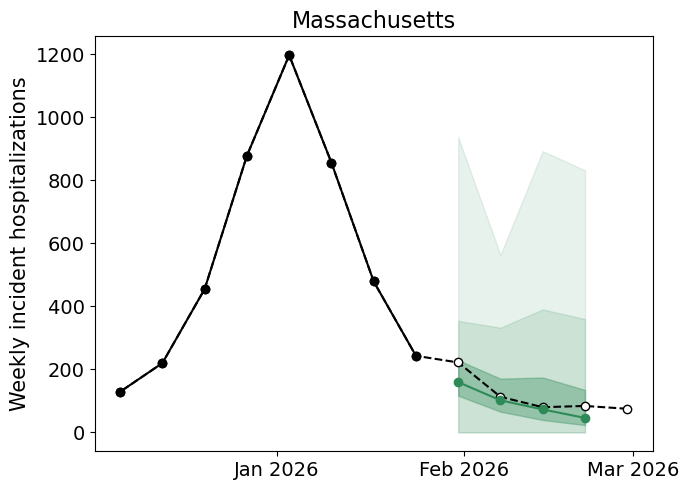

In [100]:
fig,ax = plt.subplots(1,1,figsize=(7,5))

intervals = [(0.01,0.99),(0.05,0.95),(0.25,0.75)]
map_alpha = lambda interval_range: 0.5 * (1-interval_range) + 0.1
color = 'seagreen'

locations = pd.read_csv('./locations.csv')

surv = pull_surveillance_data()
surv['date'] = pd.to_datetime(surv['date'])



d = surv[(surv.location==loc) & (surv.date>=pd.to_datetime('2025-11-30')) & (surv.date<=pd.to_datetime('2026-03-01'))]
ax.plot(d.date,d['value'],'o--',color='k',label='Out of sample', markerfacecolor='white')

d = surv[(surv.location==loc) & (surv.date>=pd.to_datetime('2025-11-30')) & (surv.date<preds.target_end_date.min())]
ax.plot(d.date,d['value'],'o-',color='k',label='Weekly incident hosp')


#dfilt = d[d.date>=pd.to_datetime(date)]
#ax[r,c].plot(dfilt.date,dfilt['value'],'o',mfc='w', mec='k')

#last_week = (pd.to_datetime(date) - timedelta(days=7)).strftime("%Y-%m-%d")  


predictions = Predictions(preds[(preds.location==loc) & (preds.horizon>=0) &\
                               (preds.target == 'wk inc flu hosp')], t_col='target_end_date', 
                          quantile_col='output_type_id', type_col='horizon')

predictions['output_type_id'] = predictions['output_type_id'].astype(float)

t = np.unique(predictions.get_t())
predictions['target_end_date'] = pd.to_datetime(predictions['target_end_date'])
 #intervals
for interval in intervals:
    q_low,q_upp = interval
    interval_range = q_upp - q_low
    alpha = map_alpha(interval_range)
    pred_low = predictions.get_quantile(q_low, )
    pred_upp = predictions.get_quantile(q_upp, )
    ax.fill_between(predictions.target_end_date.unique(),pred_upp,pred_low, color=color, alpha=alpha,
                           label=fr"PI {int(round(interval_range*100))} %")

pred_point = predictions.get_point()
if len(pred_point) > 0:
    ax.plot(predictions.target_end_date.unique(),pred_point,'-o',color=color)


set_date_axis_fmt(ax)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.set_title(locations[locations.location==loc].location_name.unique()[0], fontsize=16)    

ax.set_ylabel('Weekly incident hospitalizations', fontsize=15)

#plt.legend(fontsize=14)

plt.tight_layout()

plt.savefig('./exampleforecastLOP.pdf')

plt.show()